<a href="https://colab.research.google.com/github/VitorSoaresGoncalves/CalculoNumerico/blob/main/ATV1_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Identificação e divisão de tarefas

**Integrantes:**
- Letíca Yumi Matsune - RA: 176562
- Vitor Soares Gonçalves - RA: 176545

## Divisão das tarefas

### Pessoa 1
- Parte A — Truncamento e arredondamento
  - Cálculo das aproximações
  - Cálculo dos erros absoluto, relativo e percentual
  - Tabela de resultados
  - Gráficos de erro absoluto
  - Resposta da questão sobre arredondamento e truncamento
- Parte B — Medidas de pressão arterial
  - Construção das quatro séries de dados
  - Cálculo de média, mínimo, máximo, amplitude e desvio-padrão
  - Cálculo dos erros das médias
  - Gráficos das quatro séries
  - Gráficos dos erros
  - Histogramas
  - Análise da representação inteira

### Pessoa 2
- Parte C — Vazão em um tubo de pequeno diâmetro
  - Cálculo da vazão pela equação de Hagen–Poiseuille
  - Análise de arredondamento e truncamento das variáveis
  - Cálculo dos erros
  - Análise da sensibilidade da vazão ao raio
  - Gráficos de Q × r e dos erros
- Parte D — Escoamento em um nanocateter
  - Cálculo da vazão
  - Análise do erro geométrico
  - Comparação com a aproximação linear
  - Comparação entre float32 e float64
  - Análise de cancelamento
  - Explicação do fenômeno físico
- Parte E — Síntese visual
  - Quadro único de resultados
- Parte 8 — GIF demonstrativo
  - Geração e organização do GIF

### Tarefas realizadas em conjunto
- Revisão dos códigos
- Conferência dos cálculos, tabelas e unidades
- Revisão dos gráficos
- Revisão das respostas e conclusão
- Organização final do notebook para entrega

In [1]:
# Importa a biblioteca de funções matemáticas da linguagem Python.  (usado para funções matemáticas)
import math

# Importa a biblioteca NumPy e cria o apelido convencional np.  (usado para funções matemáticas)
import numpy as np

# Importa o módulo de gráficos pyplot e cria o apelido plt.  (usado para plotar gráfico)
import matplotlib.pyplot as plt

# Importa a biblioteca Pandas e cria o apelido pd.  (usado para plotar tabelas)
import pandas as pd

# Define um estilo visual claro para todos os gráficos do notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Importa a biblioteca imageio.v2 e cria o apelido imageio (usada para gifs)
import imageio.v2 as imageio

# Exibe uma mensagem para confirmar que a célula foi executada.
print("Ambiente preparado com sucesso!")

Ambiente preparado com sucesso!


In [2]:
#funções auxiliares

def truncar(x, n):  # Trunca o número x para n casas decimais,

    fator = 10 ** n
    return np.trunc(x * fator) / fator



# FUNÇÕES PARA CÁLCULO DOS ERROS


def erro_absoluto(x, x_aproximado):  # Calcula o erro absoluto.  Ea = |x - x̃|

    return abs(x - x_aproximado)


def erro_relativo(x, x_aproximado): # Calcula o erro relativo.  Er = |x - x̃| / |x|

    if x == 0:
        return np.nan

    return abs(x - x_aproximado) / abs(x)


def erro_percentual(x, x_aproximado): #Calcula o erro percentual. E% = 100 * Er

    Er = erro_relativo(x, x_aproximado)
    return 100 * Er

# Função de Hagen-Poiseuille

def vazao(r,mu,dp,L):
  return (np.pi * r**4 * dp)/ (8* mu * L)


# Parte A – truncamento e arredondamento

In [3]:

# valores fornecidos:

valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}

casas_decimais = [0, 1, 2, 3, 4]

# CÁLCULOS

resultados = []

for nome, x in valores.items():

    for n in casas_decimais:

        # Aproximações
        valor_truncado = truncar(x, n)
        valor_arredondado = round(x, n)

        # Erros do truncamento
        Ea_trunc = erro_absoluto(x, valor_truncado)
        Er_trunc = erro_relativo(x, valor_truncado)
        Ep_trunc = erro_percentual(x, valor_truncado)

        # Erros do arredondamento
        Ea_arred = erro_absoluto(x, valor_arredondado)
        Er_arred = erro_relativo(x, valor_arredondado)
        Ep_arred = erro_percentual(x, valor_arredondado)

        # Armazenando os resultados
        resultados.append({
            "Valor": nome,
            "Valor original": x,
            "n": n,

            "Truncamento": valor_truncado,
            "Ea truncamento": Ea_trunc,
            "Er truncamento": Er_trunc,
            "E% truncamento": Ep_trunc,

            "Arredondamento": valor_arredondado,
            "Ea arredondamento": Ea_arred,
            "Er arredondamento": Er_arred,
            "E% arredondamento": Ep_arred
        })

        tabela_resultados = pd.DataFrame(resultados)

# Mostrar todas as colunas e casas decimais
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.10f}")

display(tabela_resultados)

,Valor,Valor original,n,Truncamento,Ea truncamento,Er truncamento,E% truncamento,Arredondamento,Ea arredondamento,Er arredondamento,E% arredondamento
0,x1,3.1415926500,0,3.0000000000,0.1415926500,0.0450703404,4.5070340357,3.0000000000,0.1415926500,0.0450703404,4.5070340357
1,x1,3.1415926500,1,3.1000000000,0.0415926500,0.0132393517,1.3239351703,3.1000000000,0.0415926500,0.0132393517,1.3239351703
2,x1,3.1415926500,2,3.1400000000,0.0015926500,0.0005069562,0.0506956241,3.1400000000,0.0015926500,0.0005069562,0.0506956241
3,x1,3.1415926500,3,3.1410000000,0.0005926500,0.0001886464,0.0188646354,3.1420000000,0.0004073500,0.0001296635,0.0129663532
4,x1,3.1415926500,4,3.1415000000,0.0000926500,0.0000294914,0.0029491411,3.1416000000,0.0000073500,0.0000023396,0.0002339578
5,x2,98.7654300000,0,98.0000000000,0.7654300000,0.0077499789,0.7749978915,99.0000000000,0.2345700000,0.0023750213,0.2375021300
6,x2,98.7654300000,1,98.7000000000,0.0654300000,0.0006624788,0.0662478764,98.8000000000,0.0345700000,0.0003500213,0.0350021257
7,x2,98.7654300000,2,98.7600000000,0.0054300000,0.0000549788,0.0054978751,98.7700000000,0.0045700000,0.0000462713,0.0046271251
8,x2,98.7654300000,3,98.7650000000,0.0004300000,0.0000043538,0.0004353750,98.7650000000,0.0004300000,0.0000043538,0.0004353750
9,x2,98.7654300000,4,98.7654000000,0.0000300000,0.0000003038,0.0000303750,98.7654000000,0.0000300000,0.0000003038,0.0000303750


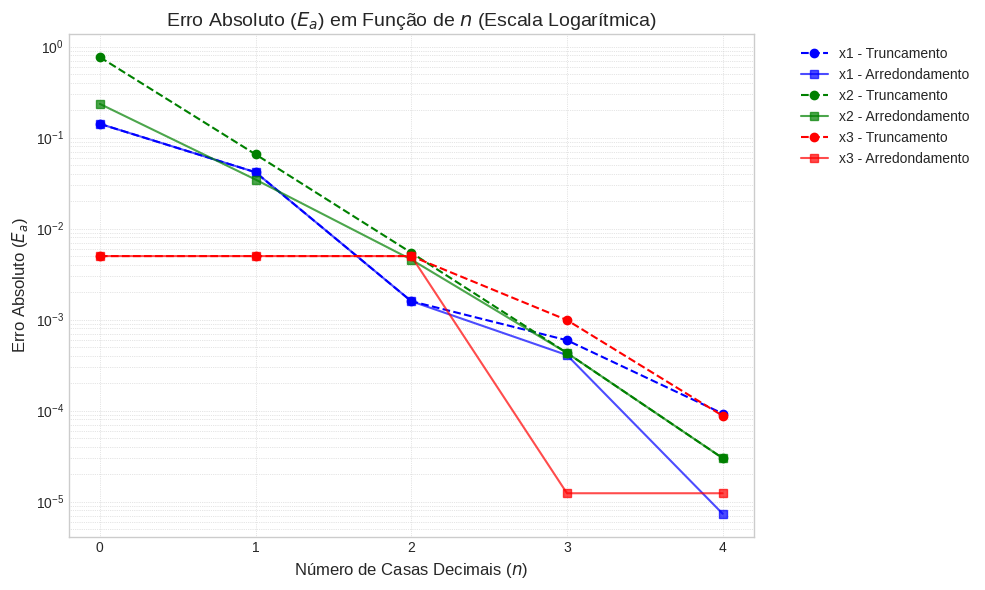

In [4]:
# Plot do gráfico

plt.figure(figsize=(10, 6))

# Cores distintas para cada variável
cores = {"x1": "blue", "x2": "green", "x3": "red"}

for nome in valores.keys():
  df_sub = tabela_resultados[tabela_resultados["Valor"] == nome]

  # Linha para Truncamento
  plt.plot(
      df_sub["n"],
      df_sub["Ea truncamento"],
      marker="o",
      linestyle="--",
      color=cores[nome],
      label=f"{nome} - Truncamento",
  )

  # Linha para Arredondamento
  plt.plot(
      df_sub["n"],
      df_sub["Ea arredondamento"],
      marker="s",
      linestyle="-",
      color=cores[nome],
      alpha=0.7,
      label=f"{nome} - Arredondamento",
  )

# Configurações do eixo logarítmico e formatação
plt.yscale("log")
plt.xlabel("Número de Casas Decimais ($n$)", fontsize=12)
plt.ylabel("Erro Absoluto ($E_a$)", fontsize=12)
plt.title(
    "Erro Absoluto ($E_a$) em Função de $n$ (Escala Logarítmica)", fontsize=14
)
plt.xticks(casas_decimais)
plt.grid(True, which="both", linestyle=":", linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

Arredondar sempre gera erro menor ou igual ao truncamento? Justifique com os
resultados.

R: De acordo como os resultados, arredondar sempre gera erro menor ou igual ao truncamento.  

# Parte B

In [5]:
# B.1 Representação das medidas

dados_originais = [
    121.7,
    120.4,
    122.1,
    119.8,
    121.2,
    120.9,
    122.4,
    121.0,
    120.2,
    121.5,
]

# 1. Construção das 3 séries solicitadas
series = {
    " Originais": dados_originais,
    " Arred. Inteiro (n=0)": [round(x) for x in dados_originais],
    " Trunc. Inteiro (n=0)": [math.trunc(x) for x in dados_originais],
}

# Média de referência (com todos os algarismos)
media_ref = np.mean(dados_originais)

# 2. Processamento estatístico e erros das médias
tabela_resultados = []

for nome, valores in series.items():
  arr = np.array(valores)
  media = np.mean(arr)
  minimo = np.min(arr)
  maximo = np.max(arr)
  amplitude = maximo - minimo
  desvio_padrao = np.std(arr, ddof=1)  # Desvio-padrão amostral

  # Cálculo dos erros em relação à média de referência
  Ea = abs(media_ref - media)
  Er = Ea / abs(media_ref)
  Ep = Er * 100

  tabela_resultados.append({
      "Série": nome,
      "Média (mmHg)": media,
      "Mínimo": minimo,
      "Máximo": maximo,
      "Amplitude": amplitude,
      "Desvio-Padrão Amostral": desvio_padrao,
      "Ea Média": Ea,
      "Er Média": Er,
      "E% Média (%)": Ep,
  })

df_parte_b = pd.DataFrame(tabela_resultados)
df_parte_b.index = range(1, len(df_parte_b) + 1)

# Exibição da tabela configurada
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
display(df_parte_b)

,Série,Média (mmHg),Mínimo,Máximo,Amplitude,Desvio-Padrão Amostral,Ea Média,Er Média,E% Média (%)
1,Originais,121.120000,119.800000,122.400000,2.600000,0.833733,0.000000,0.000000,0.000000
2,Arred. Inteiro (n=0),121.100000,120.000000,122.000000,2.000000,0.875595,0.020000,0.000165,0.016513
3,Trunc. Inteiro (n=0),120.700000,119.000000,122.000000,3.000000,0.948683,0.420000,0.003468,0.346764


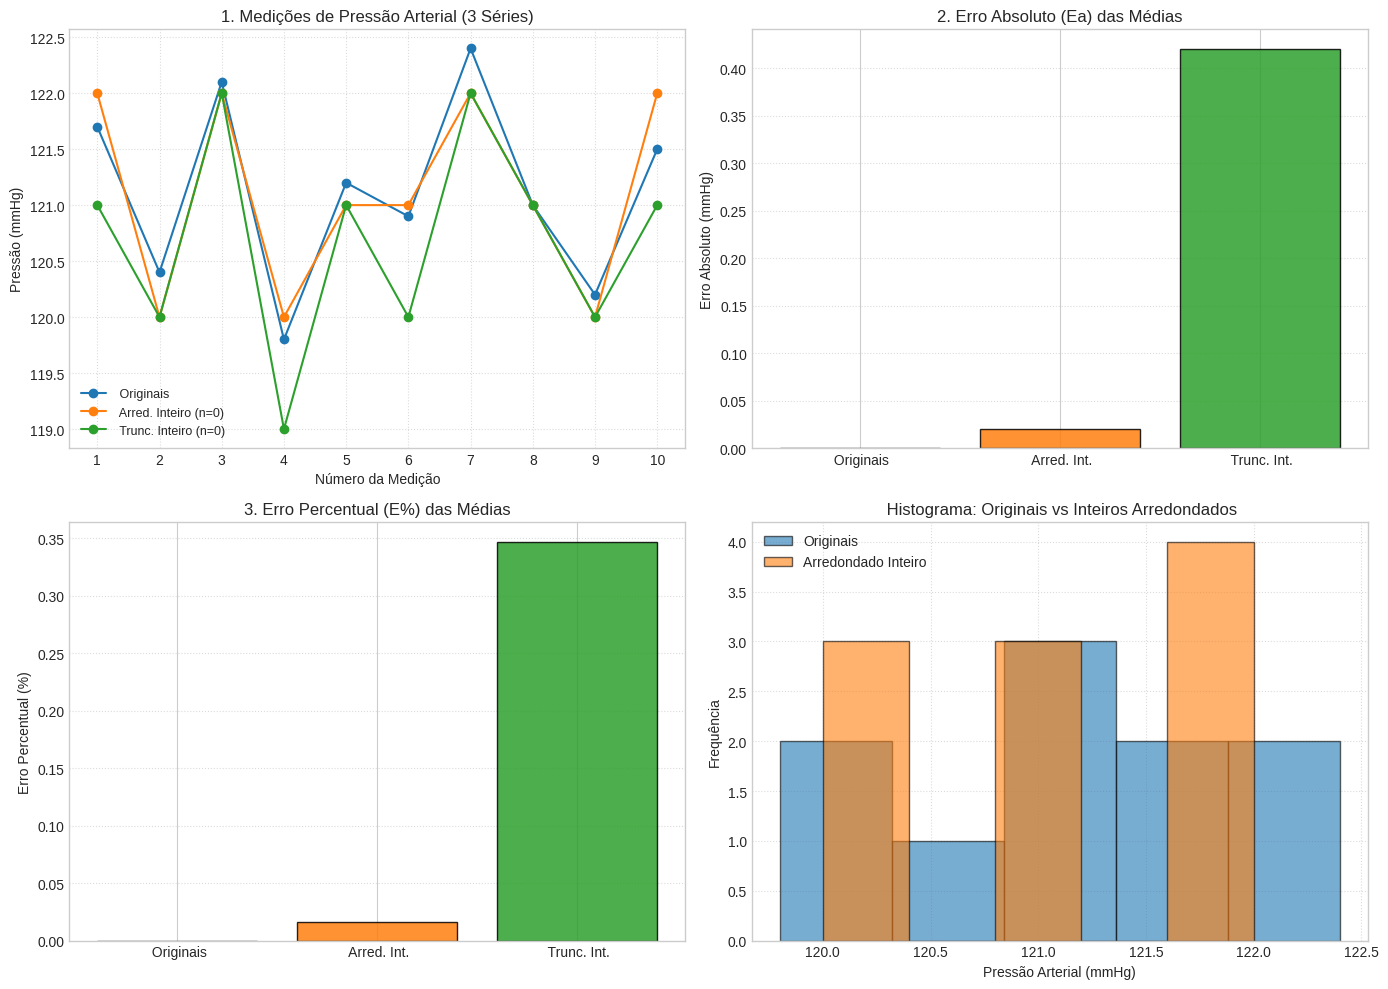

In [6]:
# Gráficos Obrigatórios (B.2) - 3 Séries

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
indices = np.arange(1, 11)
cores = ["#1f77b4", "#ff7f0e", "#2ca02c"]
nomes_series = [" Originais", " Arred. Int.", " Trunc. Int."]

# 1. Gráfico das dez medições (3 séries)
for (nome, valores), cor in zip(series.items(), cores):
  axs[0, 0].plot(
      indices, valores, marker="o", linestyle="-", label=nome, color=cor
  )

axs[0, 0].set_title("1. Medições de Pressão Arterial (3 Séries)")
axs[0, 0].set_xlabel("Número da Medição")
axs[0, 0].set_ylabel("Pressão (mmHg)")
axs[0, 0].set_xticks(indices)
axs[0, 0].legend(fontsize=9)
axs[0, 0].grid(True, linestyle=":", alpha=0.7)

# Extração dos erros
eas = [d["Ea Média"] for d in tabela_resultados]
eps = [d["E% Média (%)"] for d in tabela_resultados]

# 2. Gráfico de barras dos erros absolutos das médias
axs[0, 1].bar(nomes_series, eas, color=cores, alpha=0.85, edgecolor="black")
axs[0, 1].set_title("2. Erro Absoluto (Ea) das Médias")
axs[0, 1].set_ylabel("Erro Absoluto (mmHg)")
axs[0, 1].grid(True, axis="y", linestyle=":", alpha=0.7)

# 3. Gráfico de barras dos erros percentuais das médias
axs[1, 0].bar(nomes_series, eps, color=cores, alpha=0.85, edgecolor="black")
axs[1, 0].set_title("3. Erro Percentual (E%) das Médias")
axs[1, 0].set_ylabel("Erro Percentual (%)")
axs[1, 0].grid(True, axis="y", linestyle=":", alpha=0.7)

# 4. Histograma dos dados originais e inteiros arredondados
axs[1, 1].hist(
    series[" Originais"],
    bins=5,
    alpha=0.6,
    label="Originais",
    color=cores[0],
    edgecolor="black",
)
axs[1, 1].hist(
    series[" Arred. Inteiro (n=0)"],
    bins=5,
    alpha=0.6,
    label="Arredondado Inteiro",
    color=cores[1],
    edgecolor="black",
)
axs[1, 1].set_title(" Histograma: Originais vs Inteiros Arredondados")
axs[1, 1].set_xlabel("Pressão Arterial (mmHg)")
axs[1, 1].set_ylabel("Frequência")
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

Explique se a representação inteira é suficiente para preservar a média e a variabilidade
desta pequena amostra. Não faça interpretação médica dos valores.

R: Sim, visto que os erros no caso de truncar (pior caso), o erro absoluto não ultrapassa 0.4 unidades e o percentual é menor que 0.5% acredito que a representação inteira não traria problemas para a interpretação dos dados.

# Parte C – vazão em um tubo de pequeno diâmetro

In [7]:
# C.1 - Precisão das Variáveis

# ------------------------------------------------------------
# Dados fornecidos
# ------------------------------------------------------------

r_mm = 0.80
L = 0.20
mu = 3.5e-3
dp = 1200

# Conversão do raio para metros
r = r_mm / 1000

# ------------------------------------------------------------
# Valor de referência
# ------------------------------------------------------------

Q_ref = vazao(r, mu, dp, L)

print("Vazão de referência:")
print(f"Q = {Q_ref:.10e} m³/s")
print(f"Q = {Q_ref * 1000:.8f} L/s")

# ------------------------------------------------------------
# Aproximações
# ------------------------------------------------------------

# Raio para uma casa decimal em mm
r_arred_mm = round(r_mm, 1)
r_trunc_mm = np.floor(r_mm * 10) / 10

# Converter para metros
r_arred = r_arred_mm / 1000
r_trunc = r_trunc_mm / 1000

# Viscosidade para três casas decimais em Pa.s
mu_arred = round(mu, 3)
mu_trunc = np.floor(mu * 1000) / 1000

# Pressão para centenas de Pa
dp_arred = round(dp / 100) * 100
dp_trunc = np.floor(dp / 100) * 100

# ------------------------------------------------------------
# Cálculo das vazões
# ------------------------------------------------------------

cenarios = {
    "Referência": (r, mu, dp),

    "r arredondado": (r_arred, mu, dp),
    "r truncado": (r_trunc, mu, dp),

    "μ arredondada": (r, mu_arred, dp),
    "μ truncada": (r, mu_trunc, dp),

    "Δp arredondada": (r, mu, dp_arred),
    "Δp truncada": (r, mu, dp_trunc),

    "Todas arredondadas": (r_arred, mu_arred, dp_arred),
    "Todas truncadas": (r_trunc, mu_trunc, dp_trunc)
}

# ------------------------------------------------------------
# Tabela de resultados
# ------------------------------------------------------------

resultados = []

for nome, valores in cenarios.items():
    r_i, mu_i, dp_i = valores

    Q = vazao(r_i, mu_i, dp_i, L)

    erro_abs = abs(Q - Q_ref)
    erro_percentual = erro_abs / abs(Q_ref) * 100

    resultados.append([
        nome,
        Q,
        erro_abs,
        erro_percentual
    ])

tabela = pd.DataFrame(
    resultados,
    columns=[
        "Cenário",
        "Q (m³/s)",
        "Erro absoluto (m³/s)",
        "Erro percentual (%)"
    ]
)

display(tabela)

# ------------------------------------------------------------
# Exibição com maior precisão
# ------------------------------------------------------------

print("\nResultados detalhados:\n")

for _, linha in tabela.iterrows():
    print(linha["Cenário"])
    print(f"  Q = {linha['Q (m³/s)']:.10e} m³/s")
    print(f"  Erro absoluto = {linha['Erro absoluto (m³/s)']:.10e} m³/s")
    print(f"  Erro percentual = {linha['Erro percentual (%)']:.6f}%")
    print()

Vazão de referência:
Q = 2.7574207520e-07 m³/s
Q = 0.00027574 L/s


,Cenário,Q (m³/s),Erro absoluto (m³/s),Erro percentual (%)
0,Referência,0.000000,0.000000,0.000000
1,r arredondado,0.000000,0.000000,0.000000
2,r truncado,0.000000,0.000000,0.000000
3,μ arredondada,0.000000,0.000000,12.500000
4,μ truncada,0.000000,0.000000,16.666667
5,Δp arredondada,0.000000,0.000000,0.000000
6,Δp truncada,0.000000,0.000000,0.000000
7,Todas arredondadas,0.000000,0.000000,12.500000
8,Todas truncadas,0.000000,0.000000,16.666667



Resultados detalhados:

Referência
  Q = 2.7574207520e-07 m³/s
  Erro absoluto = 0.0000000000e+00 m³/s
  Erro percentual = 0.000000%

r arredondado
  Q = 2.7574207520e-07 m³/s
  Erro absoluto = 0.0000000000e+00 m³/s
  Erro percentual = 0.000000%

r truncado
  Q = 2.7574207520e-07 m³/s
  Erro absoluto = 0.0000000000e+00 m³/s
  Erro percentual = 0.000000%

μ arredondada
  Q = 2.4127431580e-07 m³/s
  Erro absoluto = 3.4467759399e-08 m³/s
  Erro percentual = 12.500000%

μ truncada
  Q = 3.2169908773e-07 m³/s
  Erro absoluto = 4.5957012533e-08 m³/s
  Erro percentual = 16.666667%

Δp arredondada
  Q = 2.7574207520e-07 m³/s
  Erro absoluto = 0.0000000000e+00 m³/s
  Erro percentual = 0.000000%

Δp truncada
  Q = 2.7574207520e-07 m³/s
  Erro absoluto = 0.0000000000e+00 m³/s
  Erro percentual = 0.000000%

Todas arredondadas
  Q = 2.4127431580e-07 m³/s
  Erro absoluto = 3.4467759399e-08 m³/s
  Erro percentual = 12.500000%

Todas truncadas
  Q = 3.2169908773e-07 m³/s
  Erro absoluto = 4.595701253

In [8]:
# C.2 - Sensibilidade da vazão do raio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dados constantes
# ------------------------------------------------------------

L = 0.20              # m
mu = 3.5e-3           # Pa.s
dp = 1200             # Pa

# Raios de 0,70 a 0,90 mm
r_mm = np.arange(0.70, 0.901, 0.01)

# ------------------------------------------------------------
# Função de Hagen-Poiseuille
# ------------------------------------------------------------

def vazao(r_mm, mu, dp, L):
    r_m = r_mm / 1000
    return (np.pi * r_m**4 * dp) / (8 * mu * L)

# ------------------------------------------------------------
# Arredondamento e truncamento
# ------------------------------------------------------------

# Arredondamento matemático para uma casa decimal
# (evita problemas do arredondamento binário do Python)
r_arred_mm = np.floor(r_mm * 10 + 0.5) / 10

# Truncamento para uma casa decimal
r_trunc_mm = np.floor(r_mm * 10) / 10

# ------------------------------------------------------------
# Vazões
# ------------------------------------------------------------

Q_ref = vazao(r_mm, mu, dp, L)

Q_arred = vazao(r_arred_mm, mu, dp, L)

Q_trunc = vazao(r_trunc_mm, mu, dp, L)

# ------------------------------------------------------------
# Erros
# ------------------------------------------------------------

# Erro absoluto
erro_abs_arred = np.abs(Q_arred - Q_ref)
erro_abs_trunc = np.abs(Q_trunc - Q_ref)

# Erro relativo
erro_rel_arred = erro_abs_arred / np.abs(Q_ref)
erro_rel_trunc = erro_abs_trunc / np.abs(Q_ref)

# Erro percentual
erro_pct_arred = erro_rel_arred * 100
erro_pct_trunc = erro_rel_trunc * 100

# ------------------------------------------------------------
# Tabela de resultados
# ------------------------------------------------------------

tabela = pd.DataFrame({
    "r original (mm)": r_mm,
    "r arredondado (mm)": r_arred_mm,
    "r truncado (mm)": r_trunc_mm,
    "Q referência (m³/s)": Q_ref,
    "Q arredondado (m³/s)": Q_arred,
    "Q truncado (m³/s)": Q_trunc,
    "Erro abs. arred. (m³/s)": erro_abs_arred,
    "Erro abs. trunc. (m³/s)": erro_abs_trunc,
    "Erro rel. arred.": erro_rel_arred,
    "Erro rel. trunc.": erro_rel_trunc,
    "Erro % arred.": erro_pct_arred,
    "Erro % trunc.": erro_pct_trunc
})

display(tabela.round(10))

,r original (mm),r arredondado (mm),r truncado (mm),Q referência (m³/s),Q arredondado (m³/s),Q truncado (m³/s),Erro abs. arred. (m³/s),Erro abs. trunc. (m³/s),Erro rel. arred.,Erro rel. trunc.,Erro % arred.,Erro % trunc.
0,0.700000,0.700000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.710000,0.700000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.055159,0.055159,5.515892,5.515892
2,0.720000,0.700000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106567,0.106567,10.656662,10.656662
3,0.730000,0.700000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.154525,0.154525,15.452510,15.452510
4,0.740000,0.700000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.199308,0.199308,19.930838,19.930838
5,0.750000,0.800000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.294538,0.241165,29.453827,24.116543
6,0.760000,0.800000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.227738,0.280323,22.773766,28.032272
7,0.770000,0.800000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.165191,0.316987,16.519080,31.698654
8,0.780000,0.800000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106577,0.351345,10.657674,35.134503
9,0.790000,0.800000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.051602,0.383570,5.160243,38.356996


Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente
quatro.

R: O erro no raio é amplificado na vazão porque o raio aparece na equação elevado à quarta potência. Portanto, uma pequena alteração em \(r\) tem um efeito muito maior sobre \(Q\) do que uma alteração de mesma proporção em uma variável que aparece apenas na primeira potência.

# Parte D - Escoamento em um Nanocateter

--- D.1 Amostra dos Cálculos de Erro Geométrico ---


,Δr (nm),r_ (nm),r+ (nm),Q(r_) (m³/s),Q(r) (m³/s),Q(r+) (m³/s),Ea Máx (m³/s),Er Máx,E% Máx (%),E% Linear (%)
1,1.000000e-01,4.990000e+01,5.010000e+01,3.478276e-31,3.506242e-31,3.534376e-31,2.813420e-33,8.024032e-03,8.024032e-01,8.000000e-01
2,2.000000e-01,4.980000e+01,5.020000e+01,3.450478e-31,3.506242e-31,3.562679e-31,5.643737e-33,1.609626e-02,1.609626e+00,1.600000e+00
3,3.000000e-01,4.970000e+01,5.030000e+01,3.422846e-31,3.506242e-31,3.591152e-31,8.491019e-33,2.421687e-02,2.421687e+00,2.400000e+00
4,4.000000e-01,4.960000e+01,5.040000e+01,3.395381e-31,3.506242e-31,3.619795e-31,1.135533e-32,3.238605e-02,3.238605e+00,3.200000e+00
5,5.000000e-01,4.950000e+01,5.050000e+01,3.368082e-31,3.506242e-31,3.648609e-31,1.423675e-32,4.060401e-02,4.060401e+00,4.000000e+00
6,6.000000e-01,4.940000e+01,5.060000e+01,3.340947e-31,3.506242e-31,3.677595e-31,1.713533e-32,4.887093e-02,4.887093e+00,4.800000e+00
7,7.000000e-01,4.930000e+01,5.070000e+01,3.313977e-31,3.506242e-31,3.706753e-31,2.005115e-32,5.718701e-02,5.718701e+00,5.600000e+00
8,8.000000e-01,4.920000e+01,5.080000e+01,3.287171e-31,3.506242e-31,3.736085e-31,2.298427e-32,6.555245e-02,6.555245e+00,6.400000e+00
9,9.000000e-01,4.910000e+01,5.090000e+01,3.260527e-31,3.506242e-31,3.765590e-31,2.593477e-32,7.396743e-02,7.396743e+00,7.200000e+00
10,1.000000e+00,4.900000e+01,5.100000e+01,3.234046e-31,3.506242e-31,3.795269e-31,2.890271e-32,8.243216e-02,8.243216e+00,8.000000e+00


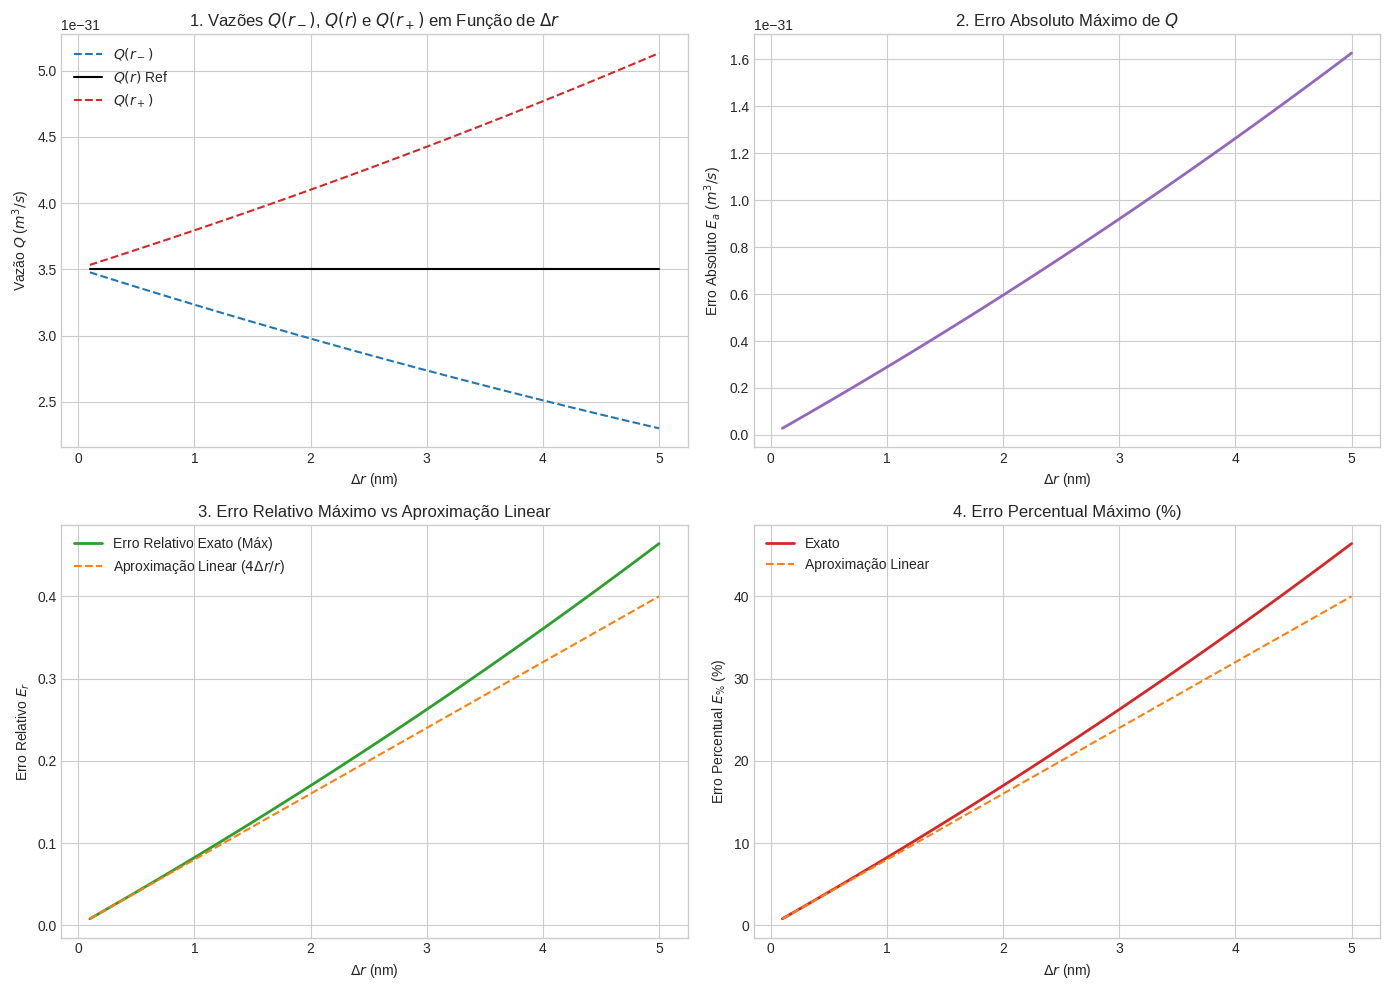

In [13]:
# Parâmetros numéricos do nanocateter (convertidos para o SI)
r_base = 50e-9  # 50 nm -> metros
L = 10e-6  # 10 µm -> metros
mu = 3.5e-3  # 3.5 x 10^-3 Pa.s
dp = 5000  # 5000 Pa

# Vazão de referência usando a função predefinida vazao()
Q_ref = vazao(r_base, mu, dp, L)

# D.1 Erro Geométrico: Variação de dr de 0.1 nm a 5.0 nm
delta_r_nm = np.arange(0.1, 5.1, 0.1)
delta_r_m = delta_r_nm * 1e-9

r_minus = r_base - delta_r_m
r_plus = r_base + delta_r_m

# Cálculo das vazões extremas utilizando a função predefinida
Q_minus = vazao(r_minus, mu, dp, L)
Q_plus = vazao(r_plus, mu, dp, L)

# Cálculo dos erros absolutos utilizando a função predefinida erro_absoluto()
Ea_minus = erro_absoluto(Q_ref, Q_minus)
Ea_plus = erro_absoluto(Q_ref, Q_plus)
Ea_max = np.maximum(Ea_minus, Ea_plus)

# Erros relativo e percentual calculados de forma vetorial direta
Er_max = Ea_max / abs(Q_ref)
Ep_max = 100 * Er_max

# Aproximação linear: dQ/Q ≈ 4 * (dr/r)
Er_aprox = 4 * (delta_r_m / r_base)
Ep_aprox = 100 * Er_aprox

# Tabela D.1 com amostra dos resultados (Índice iniciando em 1)
df_d1 = pd.DataFrame({
    "Δr (nm)": delta_r_nm,
    "r_ (nm)": r_minus * 1e9,
    "r+ (nm)": r_plus * 1e9,
    "Q(r_) (m³/s)": Q_minus,
    "Q(r) (m³/s)": Q_ref,
    "Q(r+) (m³/s)": Q_plus,
    "Ea Máx (m³/s)": Ea_max,
    "Er Máx": Er_max,
    "E% Máx (%)": Ep_max,
    "E% Linear (%)": Ep_aprox,
})
df_d1.index = range(1, len(df_d1) + 1)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6e}")
print("--- D.1 Amostra dos Cálculos de Erro Geométrico ---")
display(df_d1.head(10))

# 4 Gráficos Solicitados na Parte D.1
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gráfico de Q(r-), Q(r) e Q(r+)
axs[0, 0].plot(
    delta_r_nm, Q_minus, label=r"$Q(r_-)$", color="#1f77b4", linestyle="--"
)
axs[0, 0].plot(
    delta_r_nm,
    [Q_ref] * len(delta_r_nm),
    label=r"$Q(r)$ Ref",
    color="black",
    linewidth=1.5,
)
axs[0, 0].plot(
    delta_r_nm, Q_plus, label=r"$Q(r_+)$", color="#d62728", linestyle="--"
)
axs[0, 0].set_title(
    r"1. Vazões $Q(r_-)$, $Q(r)$ e $Q(r_+)$ em Função de $\Delta r$"
)
axs[0, 0].set_xlabel(r"$\Delta r$ (nm)")
axs[0, 0].set_ylabel(r"Vazão $Q$ ($m^3/s$)")
axs[0, 0].legend()

# 2. Erro Absoluto Máximo
axs[0, 1].plot(delta_r_nm, Ea_max, color="#9467bd", linewidth=2)
axs[0, 1].set_title(r"2. Erro Absoluto Máximo de $Q$")
axs[0, 1].set_xlabel(r"$\Delta r$ (nm)")
axs[0, 1].set_ylabel(r"Erro Absoluto $E_a$ ($m^3/s$)")

# 3. Erro Relativo Máximo vs Aproximação Linear
axs[1, 0].plot(
    delta_r_nm,
    Er_max,
    label="Erro Relativo Exato (Máx)",
    color="#2ca02c",
    linewidth=2,
)
axs[1, 0].plot(
    delta_r_nm,
    Er_aprox,
    label=r"Aproximação Linear ($4 \Delta r / r$)",
    color="#ff7f0e",
    linestyle="--",
)
axs[1, 0].set_title(r"3. Erro Relativo Máximo vs Aproximação Linear")
axs[1, 0].set_xlabel(r"$\Delta r$ (nm)")
axs[1, 0].set_ylabel(r"Erro Relativo $E_r$")
axs[1, 0].legend()

# 4. Erro Percentual Máximo
axs[1, 1].plot(delta_r_nm, Ep_max, label="Exato", color="#d62728", linewidth=2)
axs[1, 1].plot(
    delta_r_nm,
    Ep_aprox,
    label="Aproximação Linear",
    color="#ff7f0e",
    linestyle="--",
)
axs[1, 1].set_title(r"4. Erro Percentual Máximo (%)")
axs[1, 1].set_xlabel(r"$\Delta r$ (nm)")
axs[1, 1].set_ylabel(r"Erro Percentual $E_\%$ (%)")
axs[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# D.2 Precisão Computacional (float32 vs float64) e Perda de Significância

# Variáveis em precisão float32
r_f32, L_f32, mu_f32, dp_f32 = (
    np.float32(50e-9),
    np.float32(10e-6),
    np.float32(3.5e-3),
    np.float32(5000),
)
r4_f32 = r_f32**4
Q_f32 = vazao(r_f32, mu_f32, dp_f32, L_f32)
eps_f32 = np.finfo(np.float32).eps

# Variáveis em precisão float64
r_f64, L_f64, mu_f64, dp_f64 = (
    np.float64(50e-9),
    np.float64(10e-6),
    np.float64(3.5e-3),
    np.float64(5000),
)
r4_f64 = r_f64**4
Q_f64 = vazao(r_f64, mu_f64, dp_f64, L_f64)
eps_f64 = np.finfo(np.float64).eps

# Utilizando as funções predefinidas para obter a diferença absoluta e relativa
diff_abs_Q = erro_absoluto(Q_f64, Q_f32)
diff_rel_Q = erro_relativo(Q_f64, Q_f32)

df_precisao = pd.DataFrame({
    "Variável / Métrica": [
        "Epsilon da Máquina (eps)",
        "r⁴ (m⁴)",
        "Vazão Q (m³/s)",
    ],
    "float32": [eps_f32, r4_f32, Q_f32],
    "float64": [eps_f64, r4_f64, Q_f64],
    "Diferença Absoluta": [
        erro_absoluto(eps_f64, eps_f32),
        erro_absoluto(r4_f64, r4_f32),
        diff_abs_Q,
    ],
    "Diferença Relativa": [
        np.nan,
        erro_relativo(r4_f64, r4_f32),
        diff_rel_Q,
    ],
})
df_precisao.index = range(1, len(df_precisao) + 1)

print("--- D.2 Tabela 1: Comparação de Precisão (float32 vs float64) ---")
display(df_precisao)

# Análise de Cancelamento Catastrófico (δ1 vs δ2)
expoentes = np.arange(1, 16)
razoes_dr_r = 10.0 ** (-expoentes)

delta1_list = []
delta2_list = []

for dr_r in razoes_dr_r:
  dr = dr_r * r_base
  # δ1: Subtração direta de vazões
  Q_var = vazao(r_base + dr, mu, dp, L)
  d1 = (Q_var - Q_ref) / Q_ref

  # δ2: Expansão algébrica exata
  d2 = (1 + dr_r) ** 4 - 1

  delta1_list.append(d1)
  delta2_list.append(d2)

df_cancelamento = pd.DataFrame({
    "Δr / r": razoes_dr_r,
    "δ1 (Subtração Direta)": delta1_list,
    "δ2 (Fórmula Algébrica)": delta2_list,
    "Erro Relativo entre δ1 e δ2": [
        erro_relativo(d2, d1) if d2 != 0 else 0
        for d1, d2 in zip(delta1_list, delta2_list)
    ],
})
df_cancelamento.index = range(1, len(df_cancelamento) + 1)

print("\n--- D.2 Tabela 2: Cancelamento Catastrófico (δ1 vs δ2) ---")
display(df_cancelamento)